Автор: Артур Карапетян

Дата: 27.05.2026

# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
# импортируем необходимые библитеки
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from math import ceil
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# сохраним в датафрейм csv-файл с историческими данными
sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

# выведем первые пять строк датафрейма
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [3]:
# посчитаем количество уникальных сессий для каждого уникального пользователя
sessions_history_sorted = sessions_history.groupby('user_id')['session_id'].count().sort_values(ascending=False).reset_index()

# выведем данные для пользователя с наибольшим количеством сессий
user_id_with_most_sessions = sessions_history_sorted['user_id'].iloc[0]

result = sessions_history[sessions_history['user_id'] == user_id_with_most_sessions]

display(result)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

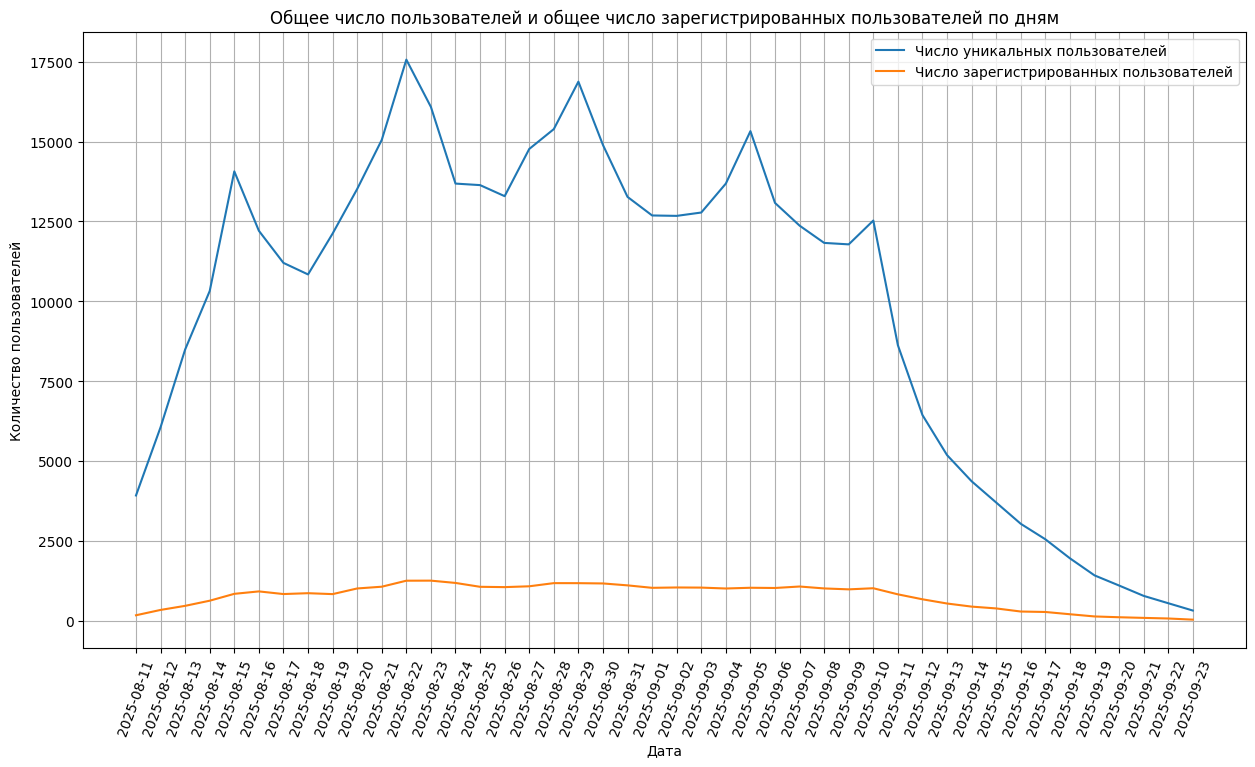

In [4]:
# посчитаем количество уникальных пользователей для каждого дня
df_merged = sessions_history.groupby('session_date').agg(
            dau=('user_id', 'nunique'),
            users_registrated=('registration_flag', 'sum')
            ).reset_index().rename(columns={'session_date': 'date'})

# построим линейные графики
plt.figure(figsize=(15, 8))
plt.plot(df_merged['date'], df_merged['dau'], label='Число уникальных пользователей')
plt.plot(df_merged['date'], df_merged['users_registrated'], label='Число зарегистрированных пользователей')

plt.title('Общее число пользователей и общее число зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')
plt.grid()
plt.legend()
plt.xticks(rotation=70)
plt.show()

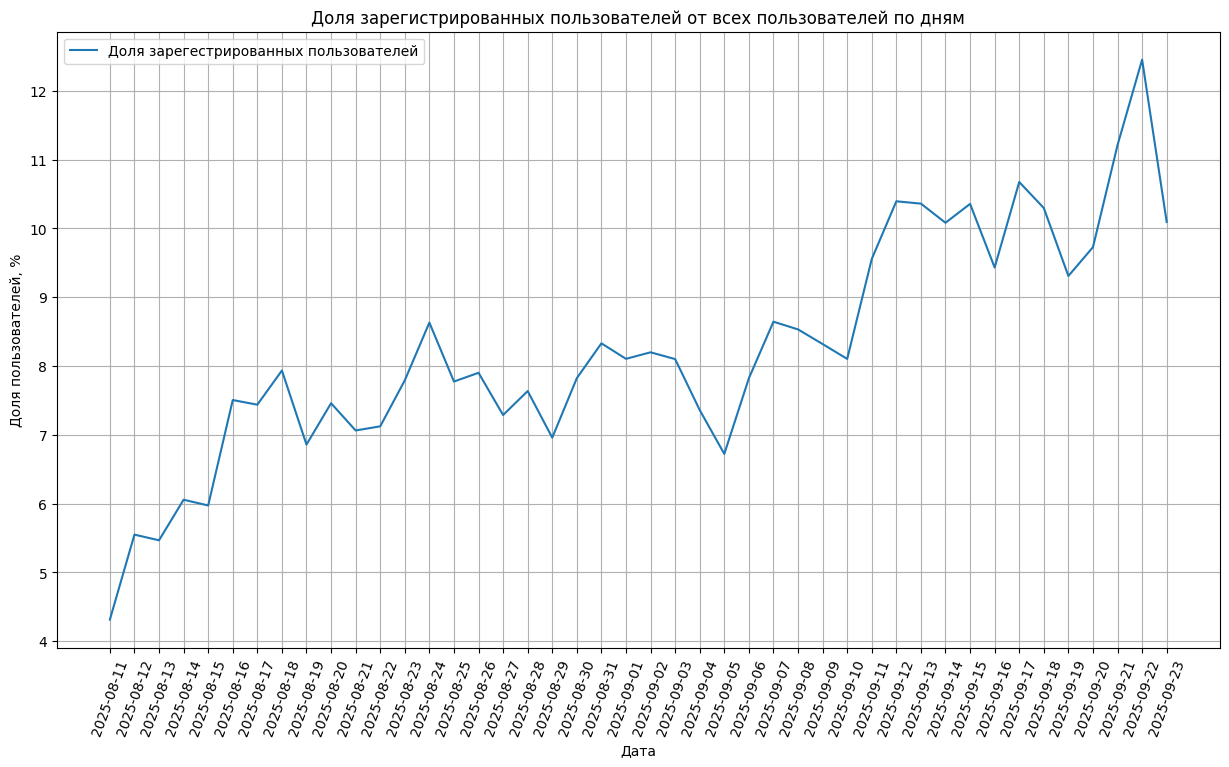

In [5]:
# посчитаем долю зарегистрированных пользователей
df_merged['registrated_ratio'] = df_merged['users_registrated'] / df_merged['dau'] * 100

# построим линейный график
plt.figure(figsize=(15, 8))
plt.plot(df_merged['date'], df_merged['registrated_ratio'], label='Доля зарегестрированных пользователей')

plt.title('Доля зарегистрированных пользователей от всех пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля пользователей, %')
plt.grid()
plt.legend()
plt.xticks(rotation=70)
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

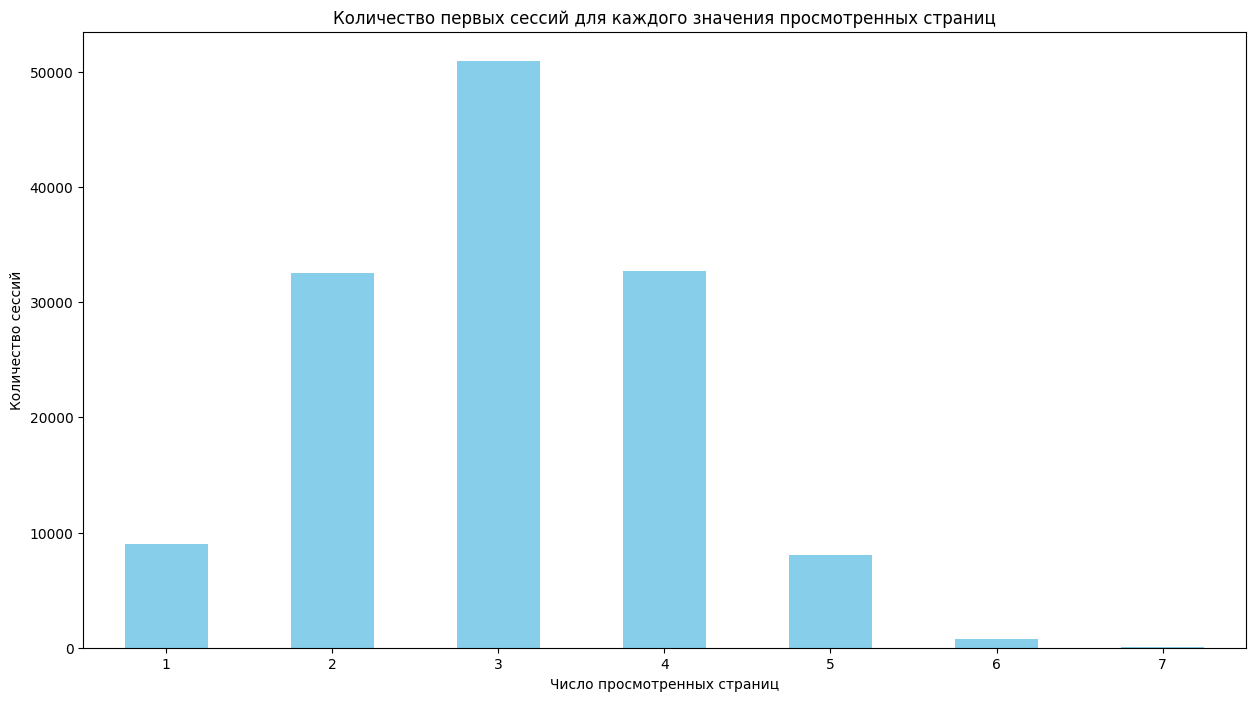

In [6]:
# посчитаем количество первых сессий для каждого значения количества просмотренных страниц
first_sessions = sessions_history[sessions_history.session_number==1]
first_sessions_grp = first_sessions.groupby('page_counter')['session_number'].sum()

# построим столбчатую диаграмму
plt.figure(figsize=(15, 8))
first_sessions_grp.plot(kind='bar',
                       title='Количество первых сессий для каждого значения просмотренных страниц',
                       legend=False,
                       ylabel='Количество сессий',
                       xlabel='Число просмотренных страниц',
                       rot=0,
                       color='skyblue')
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

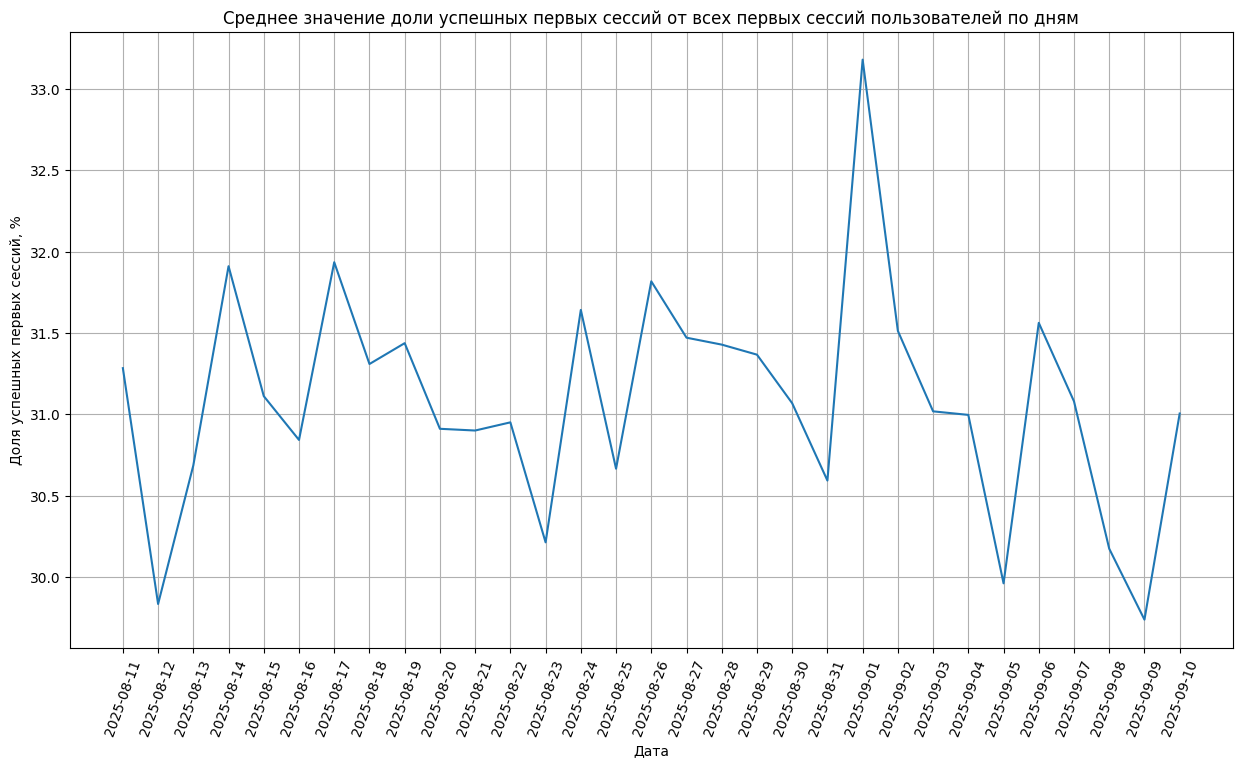

In [7]:
# создадим столбец good_session
sessions_history['good_session'] = ((sessions_history.session_number==1)&(sessions_history.page_counter >= 4)).astype(int)

# посчитаем среднее количество удачных первых сессий от общего количества первых сессий
first_sessions = sessions_history[sessions_history.session_number==1]
grp_good_ratio = first_sessions.groupby('session_date').agg(
                                                        total_good_sessions=('good_session', 'sum'),
                                                        total_first_sessions=('session_number', 'sum')).reset_index()
grp_good_ratio['good_sessions_ratio'] = grp_good_ratio.total_good_sessions / grp_good_ratio.total_first_sessions * 100

# построим линейный график
plt.figure(figsize=(15, 8))
plt.plot(grp_good_ratio['session_date'], grp_good_ratio['good_sessions_ratio'])
plt.title('Среднее значение доли успешных первых сессий от всех первых сессий пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля успешных первых сессий, %')
plt.grid()
plt.xticks(rotation=70)
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [8]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1- beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03*p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [9]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

P = 0.74%


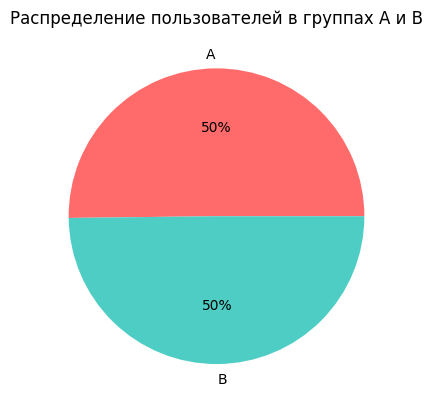

In [10]:
# сохраним в датафрейм CSV-файл с историческими данными
sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

# рассчитаем количество уникальных пользователей в каждой из экспериментальных групп
test_groups = sessions_test_part.groupby('test_group')['user_id'].nunique()

# рассчитаем процентную разницу в количестве пользователей в группах А и В
P = 100 * abs(test_groups.loc['A'] - 
              test_groups.loc['B']) / test_groups.loc['A']
print(f'P = {round(P, 2)}%')

# построим круговую диаграмму для сравнения количества пользователей групп
test_groups.plot(kind='pie',
                title='Распределение пользователей в группах А и В',
                ylabel='',
                autopct= '%.0f%%',
                colors=['#FF6B6B', '#4ECDC4'])
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [11]:
# разделим пользователей из групп А и В в разные датафреймы
users_a = sessions_test_part[sessions_test_part['test_group']=='A']['user_id']
users_b = sessions_test_part[sessions_test_part['test_group']=='B']['user_id']

# соединим получившиеся датафреймы по общим пользователям
common_users = pd.merge(users_a, users_b, on='user_id', how='inner')

# выводим количество строк в объединенном датафрейме
print(f'Количество пользователей, которые встречаются одновременно в группах A и B равно {common_users.shape[0]}')

Количество пользователей, которые встречаются одновременно в группах A и B равно 0


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


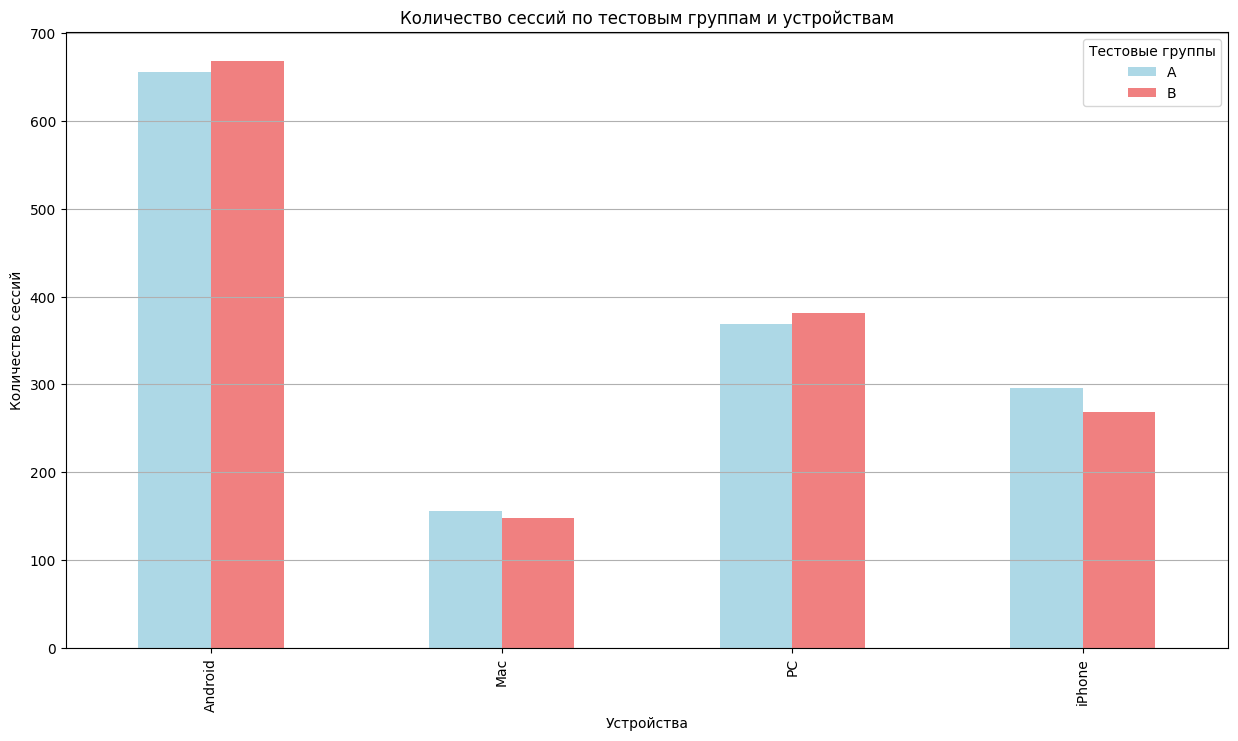

In [12]:
# группируем данные по устройствам и тестовым группам
devices = sessions_test_part.groupby(['device', 'test_group'])['user_id'].nunique().unstack(fill_value=0)

# строим столбчатую диаграмму
devices.plot(kind='bar',
             title='Количество сессий по тестовым группам и устройствам',
             figsize=(15, 8),
             color=['lightblue', 'lightcoral'])
plt.xlabel('Устройства')
plt.ylabel('Количество сессий')
plt.legend(title='Тестовые группы')
plt.grid(axis='y')
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

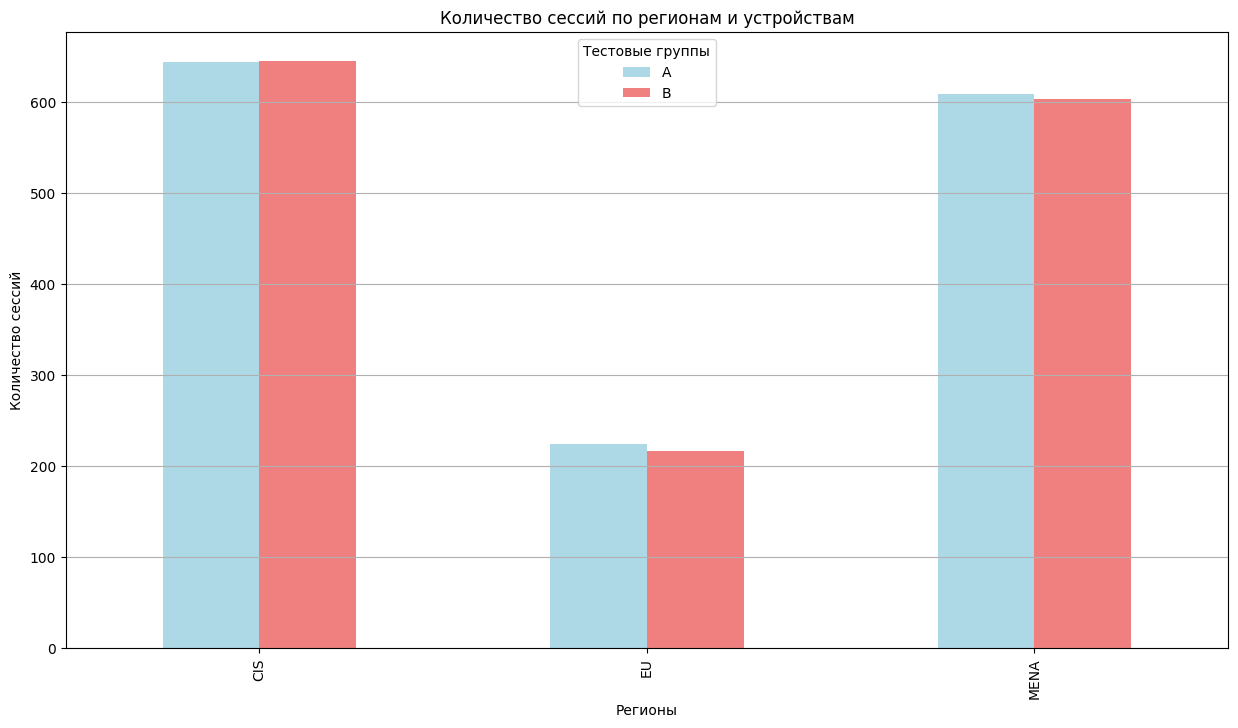

In [13]:
# группируем данные по регионам и тестовым группам
regions = sessions_test_part.groupby(['region', 'test_group'])['user_id'].nunique().unstack(fill_value=0)

# строим столбчатую диаграмму
regions.plot(kind='bar',
             title='Количество сессий по регионам и устройствам',
             figsize=(15, 8),
             color=['lightblue', 'lightcoral'])
plt.xlabel('Регионы')
plt.ylabel('Количество сессий')
plt.legend(title='Тестовые группы')
plt.grid(axis='y')
plt.show()

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**Из проведенного анализа A/B-теста следует:**
* Количество уникальных пользователей распределены между группами равными долями по 50%;
* Контрольная и тестовая группы не содержат пересечений. Каждый пользователь входит только в одну группу;
* В распределении пользователей по категориальным переменным наблюдается примерно одинаковое. Контрольная и тестовая группы имеют незначительные различия по количеству устройств и регионам.

Дизайн эксперимента соответствует стандартам проведения A/B‑тестов. Распределение пользователей обеспечивает статистическую надёжность. Изоляция групп гарантирует, что наблюдаемые эффекты связаны именно с тестируемым фактором. Умеренный разброс по техническим и географическим характеристикам повышает внешнюю валидность теста — результаты, скорее всего, можно будет обобщить на всю целевую аудиторию. Это позволяет перейти к анализу ключевых метрик и интерпретации результатов теста с уверенностью в их достоверности. 

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [14]:
# сохраним CSV-файл с историческими данными о сессиях пользователей
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

# создадим столбец good_session
sessions_test['good_session'] = (sessions_test.session_number == 1)&(sessions_test.page_counter >= 4).astype(int)

#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

Сформулируем нулевую и альтернативную гипотезы:
* *Нулевая гипотеза H0: новый алгоритм рекомендаций не повлияет на долю успешных первых сессий*
* *Альтернативная гипотеза H1: новый алгоритм рекомендаций увеличивает долю успешных первых сессий*

**Целевой метрикой** в эксперименте выступает доля успешных первых сессий.
В качестве **прокси-метрики** можно использовать среднее количество просмотренных страниц в первой сессии.Это непрерывная метрика, которая обладает гораздо большей статистической мощностью и чувствительностью, чем бинарная доля успехов. Статистический тест (t-тест) заметит даже небольшое среднее улучшение (например, рост с 2.3 до 2.6 страниц) на гораздо меньшей выборке данных.
А в качестве **барьерной метрики** подойдёт доля «отказов» (Bounce Rate) - количетво сессий ровно с 1 просмотренной страницей (page_counter == 1). Метрика контролирует базовую работоспособность и релевантность. Если новый алгоритм начнет сбоить, выдавать технические ошибки, долго грузиться или предлагать отталкивающий контент, пользователи будут закрывать приложение сразу после входа. Резкий рост этой доли — прямой сигнал к немедленной остановке теста.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [15]:
# рассчитаем долю успешных первых сессий для выборки А
p_a = len(sessions_test[(sessions_test.test_group == 'A')&
                                    (sessions_test.good_session == 1)]) / len(sessions_test[(sessions_test.test_group == 'A')&(sessions_test.session_number == 1)])

# рассчитаем долю успешных первых сессий для выборки В
p_b = len(sessions_test[(sessions_test.test_group == 'B')&
                                    (sessions_test.good_session == 1)]) / len(sessions_test[(sessions_test.test_group == 'B')&(sessions_test.session_number == 1)])

print(f'Доля успешных первых сессий для выборки А равна {p_a:.2%}')
print(f'Доля успешных первых сессий для выборки B равна {p_b:.2%}')
print(f'Разница между показателями: A - B = {(p_a - p_b):.2%}')

Доля успешных первых сессий для выборки А равна 31.57%
Доля успешных первых сессий для выборки B равна 31.47%
Разница между показателями: A - B = 0.11%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [16]:
# посчитаем размер группы А
n_a = len(sessions_test[(sessions_test['test_group'] == 'A')&(sessions_test['session_number'] == 1)])

# посчитаем размер группы B
n_b = len(sessions_test[(sessions_test['test_group'] == 'B')&(sessions_test['session_number'] == 1)])

# посчитаем количество успехов в группе А
m_a = len(sessions_test[(sessions_test['test_group'] == 'A')&
                                    (sessions_test['good_session'] == 1)])

# посчитаем количество успехов в группе B
m_b = len(sessions_test[(sessions_test['test_group'] == 'B')&
                                    (sessions_test['good_session'] == 1)])

# проверим предпосылку о достаточном количестве данных
if (p_a*n_a > 10) and ((1-p_a)*n_a > 10) and (p_b*n_b > 10) and ((1-p_b)*n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется')
    
# проведем Z-тест пропорций
stat_ztest, p_value_ztest = proportions_ztest([m_a, m_b], [n_a, n_b], alternative = 'smaller')
p_value_ztest

print(f'p-value = {p_value_ztest}')

if p_value_ztest > alpha:
    print('Нулевая гипотеза находит подтверждение')
else:
    print('Нулевая гипотеза не находит подтверждения')
    
print('Новый алгоритм рекомендаций не увеличивает количество страниц, просмотренных пользователем во время сессии')

Предпосылка о достаточном количестве данных выполняется
p-value = 0.5783523649187868
Нулевая гипотеза находит подтверждение
Новый алгоритм рекомендаций не увеличивает количество страниц, просмотренных пользователем во время сессии


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Таким образом, были сформулированы гипотезы:
* Нулевая гипотеза H0: новый алгоритм рекомендаций не повлияет на количество страниц, просмотренных пользователем во время сессии
* Альтернативная гипотеза H1: новый алгоритм рекомендаций увеличивает количество страниц, просмотренных пользователем во время сессии

Для проверки гипотез был проведен A/B-тест, в котором было задействовано 30579 пользователей. Длительность эксперимента составила 20 дней (с 2025-10-14 по 2025-11-02). Установлены следующие параметры:
* Уровень значимости — 0.05
* Вероятность ошибки второго рода — 0.2
* Мощность теста
* Минимальный детектируемый эффект — 3%

Так как целевой метрикой в эксперименте выступает доля успешных первых сессий был использован **Z-тест пропорций**.
Значение p-value составило ~0.6. Так как значение p-value оказалось больше уровня статистической значимости, делаем вывод о том, что нулевая гипотеза находит подтверждение. Новый алгоритм рекомендаций не увеличивает количество страниц, просмотренных пользователем во время первой сессии.
***Вывод: нововведение не стоит внедрять в приложение.***